In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset load karo
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Pehli 5 rows dekho
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
# Dataset ki basic info
print("Shape:", df.shape)
print("\nColumn names:\n", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())
print("\nChurn value counts:\n", df['Churn'].value_counts())

Shape: (7043, 21)

Column names:
 ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Missing values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Churn value counts:
 Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [7]:
# TotalCharges column numeric karo (abhi string hai)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Jo bhi missing values aayi hain unhe drop karo
df.dropna(inplace=True)

# Churn column ko 0/1 mein convert karo
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Cleaning done!")
print("New shape:", df.shape)

Cleaning done!
New shape: (7032, 21)


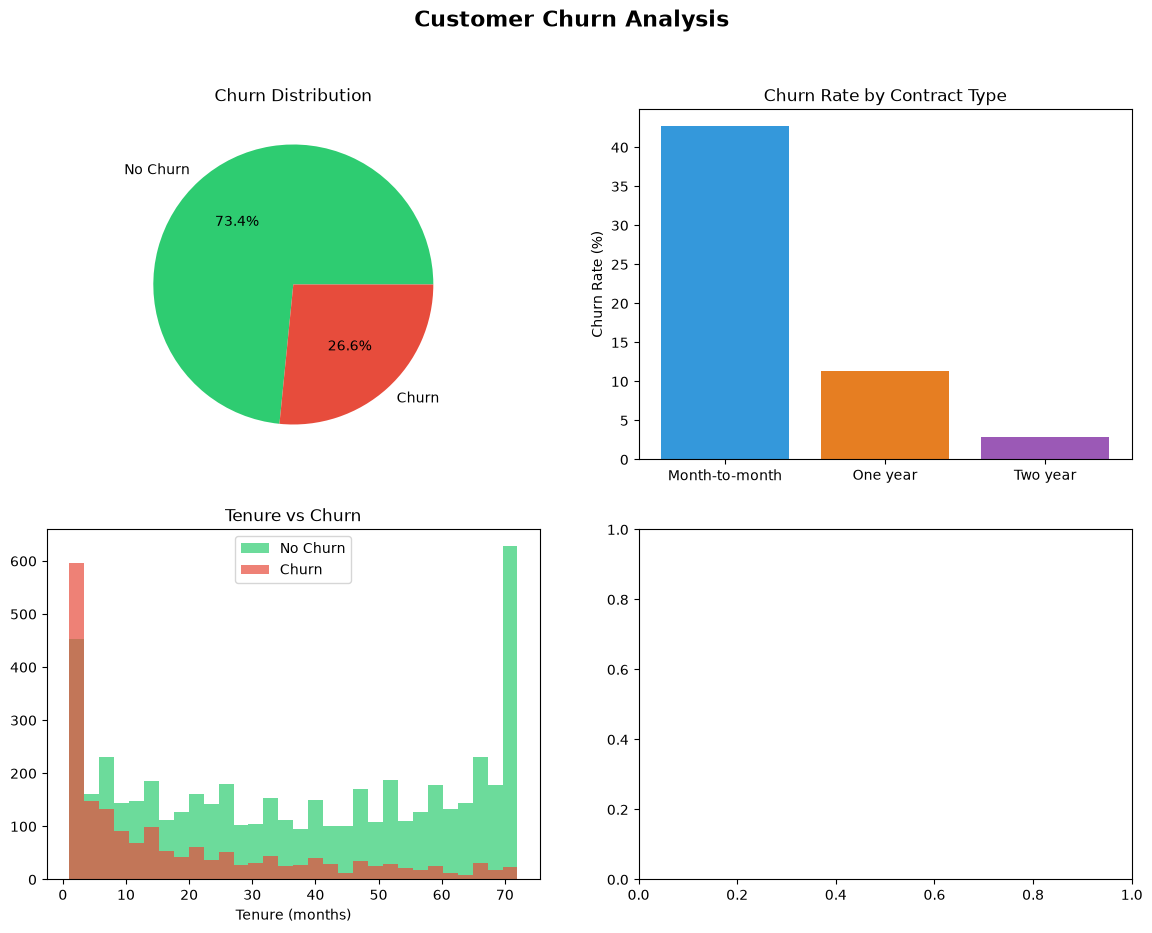

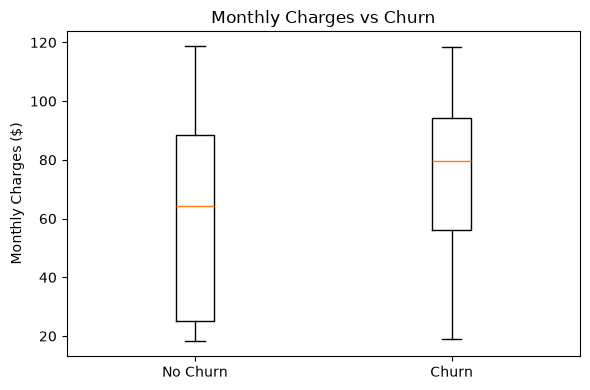

Done!


In [9]:
# Figure size set karo
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Customer Churn Analysis', fontsize=16, fontweight='bold')

# 1. Churn distribution
churn_counts = df['Churn'].value_counts()
axes[0,0].pie(churn_counts, labels=['No Churn', 'Churn'], autopct='%1.1f%%', colors=['#2ecc71','#e74c3c'])
axes[0,0].set_title('Churn Distribution')

# 2. Contract type vs Churn
contract_churn = df.groupby('Contract')['Churn'].mean() * 100
axes[0,1].bar(contract_churn.index, contract_churn.values, color=['#3498db','#e67e22','#9b59b6'])
axes[0,1].set_title('Churn Rate by Contract Type')
axes[0,1].set_ylabel('Churn Rate (%)')

# 3. Tenure distribution
axes[1,0].hist(df[df['Churn']==0]['tenure'], bins=30, alpha=0.7, label='No Churn', color='#2ecc71')
axes[1,0].hist(df[df['Churn']==1]['tenure'], bins=30, alpha=0.7, label='Churn', color='#e74c3c')
axes[1,0].set_title('Tenure vs Churn')
axes[1,0].set_xlabel('Tenure (months)')
axes[1,0].legend()

# 4. Monthly Charges vs Churn - fixed
fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot([df[df['Churn']==0]['MonthlyCharges'].values, 
            df[df['Churn']==1]['MonthlyCharges'].values],
            tick_labels=['No Churn', 'Churn'])
ax.set_title('Monthly Charges vs Churn')
ax.set_ylabel('Monthly Charges ($)')
plt.tight_layout()
plt.savefig('monthly_charges.png', dpi=150, bbox_inches='tight')
plt.show()
print("Done!")

In [10]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Categorical columns encode karo
df_model = df.copy()
le = LabelEncoder()
cat_cols = df_model.select_dtypes(include='object').columns
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

# Features aur target alag karo
X = df_model.drop(['customerID', 'Churn'], axis=1)
y = df_model['Churn']

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model train karo
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Accuracy check karo
y_pred = model.predict(X_test)
print("Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("\nReport:\n", classification_report(y_test, y_pred))

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_17596\3797875288.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_model.select_dtypes(include='object').columns


Accuracy: 79.25 %

Report:
               precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.49      0.56       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [11]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression try karo
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

print("Logistic Regression Accuracy:", round(accuracy_score(y_test, lr_pred) * 100, 2), "%")

Logistic Regression Accuracy: 78.68 %


C:\Users\LENOVO\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [12]:
from sklearn.ensemble import GradientBoostingClassifier

# Gradient Boosting try karo
gb_model = GradientBoostingClassifier(n_estimators=200, random_state=42)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

print("Gradient Boosting Accuracy:", round(accuracy_score(y_test, gb_pred) * 100, 2), "%")

Gradient Boosting Accuracy: 79.18 %


In [13]:
from sklearn.ensemble import RandomForestClassifier

# Tuned Random Forest
tuned_model = RandomForestClassifier(
    n_estimators=200, 
    max_depth=10,
    min_samples_split=5,
    random_state=42
)
tuned_model.fit(X_train, y_train)
tuned_pred = tuned_model.predict(X_test)

print("Tuned Random Forest Accuracy:", round(accuracy_score(y_test, tuned_pred) * 100, 2), "%")

Tuned Random Forest Accuracy: 79.89 %


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_17596\1566878654.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_imp.values, y=feature_imp.index, palette='RdYlGn_r')


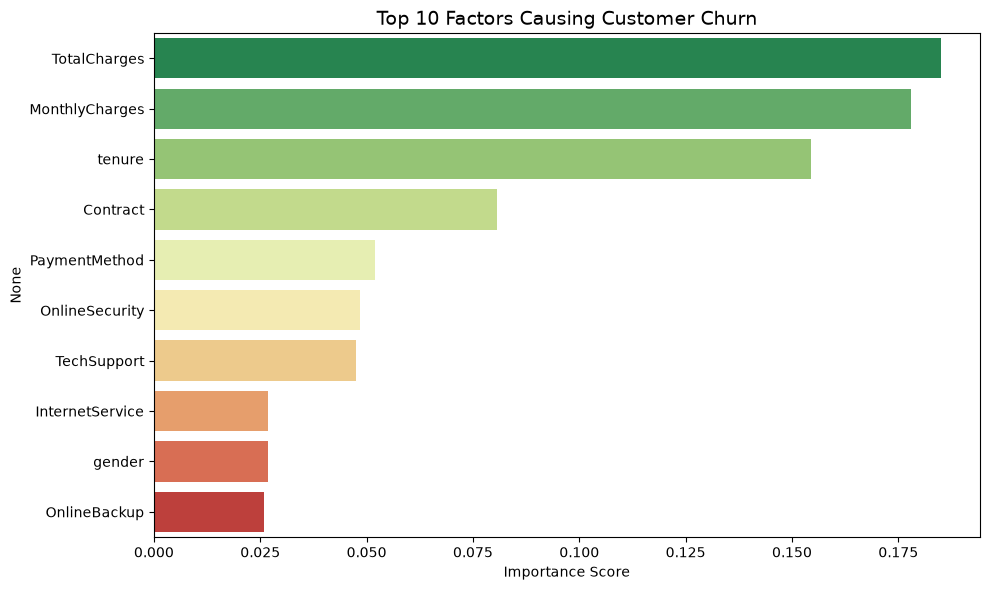

Done!


In [14]:
# Top churn factors dikhao
feature_imp = pd.Series(model.feature_importances_, index=X.columns)
feature_imp = feature_imp.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_imp.values, y=feature_imp.index, palette='RdYlGn_r')
plt.title('Top 10 Factors Causing Customer Churn', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Done!")
